![Institut Universitaire de Saint Jean](Logo-Institut-USJ-INGENIEUR.png)

# statistiques multivariees - Projet de Travail Pratique
## Theme : Facteurs qui influencent l'acces au soins postnateau

**Etudiants :**
- Johan Frederic ZINTCHEM 



**Enseignant :** Prof. NGUEFACK
**Institution :** Institut Saint Jean, Master 1 Data Science

## j'importe les bibliotheques

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_auc_score

from scipy.stats import chi2_contingency
import statsmodels.formula.api as smf
import statsmodels.api as sm

import pickle



## je charge le dataset en precisant le separateur

In [100]:
df = pd.read_csv('EDS_Cameroun_PNC_propre.csv', sep= ",")

In [101]:
df.head()

,M62$1,V012,V106,V025,V024,V190,V130,V501,V714,V157,...,residence,richesse,mariage,occupation,media,CPN,lieu_acc,parite,distance,poids
0,1,31,2,1,5,2,1,1,1,0,...,Urbain,Pauvre,Marie(e),Oui,Non,4+,Etablissement,2-3,Pas de probleme,0.990064
1,1,22,2,1,5,4,4,1,1,1,...,Urbain,Riche,Marie(e),Oui,Oui,4+,Etablissement,1,Probleme,0.990064
2,0,20,1,1,5,3,4,1,0,0,...,Urbain,Moyen,Marie(e),Non,Non,1-3,Etablissement,1,Probleme,0.990064
3,0,40,0,1,5,3,4,1,0,0,...,Urbain,Moyen,Marie(e),Non,Non,1-3,Etablissement,4+,Pas de probleme,0.990064
4,1,16,1,1,5,2,4,1,0,0,...,Urbain,Pauvre,Marie(e),Non,Non,4+,Etablissement,1,Probleme,0.990064


## nombre de lignes et de colonnes

In [102]:
df.shape

(4548, 31)

## les infos sur les colonnes

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4548 entries, 0 to 4547
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   M62$1        4548 non-null   int64  
 1   V012         4548 non-null   int64  
 2   V106         4548 non-null   int64  
 3   V025         4548 non-null   int64  
 4   V024         4548 non-null   int64  
 5   V190         4548 non-null   int64  
 6   V130         4548 non-null   int64  
 7   V501         4548 non-null   int64  
 8   V714         4548 non-null   int64  
 9   V157         4548 non-null   int64  
 10  V158         4548 non-null   int64  
 11  V467C        4548 non-null   int64  
 12  V467D        4548 non-null   int64  
 13  M14$1        4548 non-null   int64  
 14  M15$1        4548 non-null   int64  
 15  V218         4548 non-null   int64  
 16  V213         4548 non-null   int64  
 17  V005         4548 non-null   int64  
 18  PNC          4548 non-null   int64  
 19  age_gr

## identifiaction des valeurs manquantes

In [104]:
df.isnull().sum()

M62$1          0
V012           0
V106           0
V025           0
V024           0
V190           0
V130           0
V501           0
V714           0
V157           0
V158           0
V467C          0
V467D          0
M14$1          0
M15$1          0
V218           0
V213           0
V005           0
PNC            0
age_groupe     0
instruction    0
residence      0
richesse       0
mariage        0
occupation     0
media          0
CPN            0
lieu_acc       0
parite         0
distance       0
poids          0
dtype: int64

In [105]:
df["PNC"].value_counts()

PNC
1    3565
0     983
Name: count, dtype: int64

In [106]:
df["PNC"].value_counts(normalize=True)*100

PNC
1    78.386104
0    21.613896
Name: proportion, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

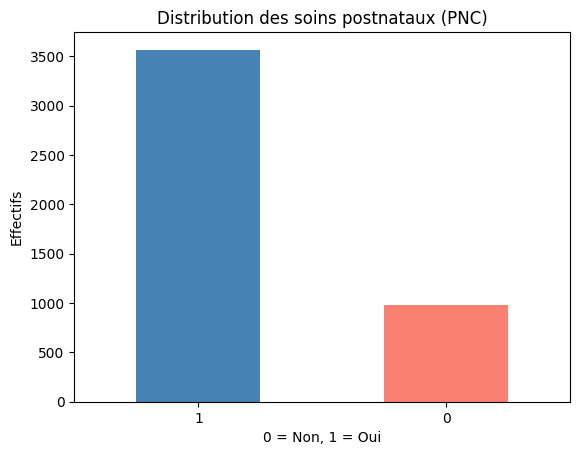

In [107]:
df["PNC"].value_counts().plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Distribution des soins postnataux (PNC)")
plt.xlabel("0 = Non, 1 = Oui")
plt.ylabel("Effectifs")
plt.xticks(rotation=0)
plt.show

In [108]:
df["age_groupe"].value_counts()

age_groupe
20-34    3202
35-49     920
15-19     426
Name: count, dtype: int64

In [109]:
df["instruction"].value_counts()

instruction
Secondaire    2316
Primaire      1398
Aucun          468
Superieur      366
Name: count, dtype: int64

In [110]:
df.describe()

,M62$1,V012,V106,V025,V024,V190,V130,V501,V714,V157,V158,V467C,V467D,M14$1,M15$1,V218,V213,V005,PNC,poids
count,4548.000000,4548.000000,4548.000000,4548.00000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4548.000000,4.548000e+03,4548.000000,4548.000000
mean,0.783861,28.382366,1.567282,1.41007,6.557168,3.376649,2.514952,1.330915,0.653474,0.282322,0.672603,1.329595,1.645778,6.260554,25.136544,3.019789,0.107080,9.960897e+05,0.783861,0.996090
std,0.411655,6.810387,0.782536,0.49190,3.441750,1.216574,6.031622,1.144591,0.475915,0.572345,0.809758,0.470118,0.478329,10.812742,4.940869,1.929721,0.309249,6.247490e+05,0.411655,0.624749
min,0.000000,15.000000,0.000000,1.00000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,21.000000,1.000000,0.000000,2.529500e+04,0.000000,0.025295
25%,1.000000,23.000000,1.000000,1.00000,3.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.000000,21.000000,1.000000,0.000000,5.667440e+05,1.000000,0.566744
50%,1.000000,28.000000,2.000000,1.00000,7.000000,3.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.000000,2.000000,5.000000,22.000000,3.000000,0.000000,8.447380e+05,1.000000,0.844738
75%,1.000000,33.000000,2.000000,2.00000,9.000000,4.000000,3.000000,2.000000,1.000000,0.000000,1.000000,2.000000,2.000000,6.000000,31.000000,4.000000,0.000000,1.235090e+06,1.000000,1.235090
max,1.000000,49.000000,3.000000,2.00000,12.000000,5.000000,96.000000,5.000000,1.000000,2.000000,2.000000,2.000000,2.000000,98.000000,36.000000,12.000000,1.000000,5.250016e+06,1.000000,5.250016


In [111]:
df["residence"].value_counts()

residence
Urbain    2683
Rural     1865
Name: count, dtype: int64

In [112]:
df["richesse"].value_counts()

richesse
Riche          1196
Moyen          1181
Plus riche     1006
Pauvre          835
Plus pauvre     330
Name: count, dtype: int64

In [113]:
df["mariage"].value_counts()

mariage
Marie(e)       2352
Autre          1153
Concubinage    1043
Name: count, dtype: int64

In [114]:
df["occupation"].value_counts()

occupation
Oui    2972
Non    1576
Name: count, dtype: int64

In [115]:
df["media"].value_counts()

media
Non    3474
Oui    1074
Name: count, dtype: int64

In [116]:
df["CPN"].value_counts()

CPN
4+        3579
1-3        868
Aucune     101
Name: count, dtype: int64

In [117]:
df["M15$1"].value_counts()

M15$1
22    1383
21    1256
33     522
32     486
31     438
23     417
34      42
36       4
Name: count, dtype: int64

In [118]:
df = df.drop(columns=["lieu_acc", "M15$1"])
df.shape

(4548, 29)

In [119]:
df["parite"].value_counts()

parite
2-3    1766
4+     1550
1      1232
Name: count, dtype: int64

In [120]:
df["distance"].value_counts()

distance
Pas de probleme    3049
Probleme           1499
Name: count, dtype: int64

In [121]:
df["V024"].value_counts()

V024
9     583
2     545
10    494
12    480
3     416
4     368
6     367
7     316
5     309
8     308
1     234
11    128
Name: count, dtype: int64

In [122]:
region_map = {
    1: "Adamaoua", 2: "Centre", 3: "Est",
    4: "Extreme-Nord", 5: "Littoral", 6: "Nord",
    7: "Nord-Ouest", 8: "Ouest", 9: "Sud", 10: "Sud-Ouest"
}

df["region"] = df["V024"].map(region_map)
df["region"].value_counts()

region
Sud             583
Centre          545
Sud-Ouest       494
Est             416
Extreme-Nord    368
Nord            367
Nord-Ouest      316
Littoral        309
Ouest           308
Adamaoua        234
Name: count, dtype: int64

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_17208\2493930909.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="PNC", data=df, palette=["salmon", "steelblue"])


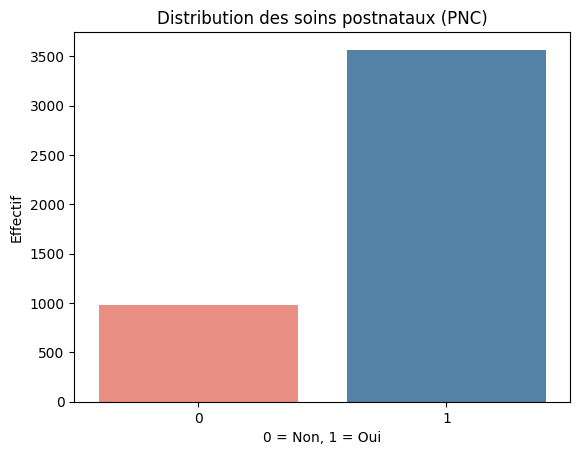

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="PNC", data=df, palette=["salmon", "steelblue"])
plt.title("Distribution des soins postnataux (PNC)")
plt.xlabel("0 = Non, 1 = Oui")
plt.ylabel("Effectif")
plt.show()

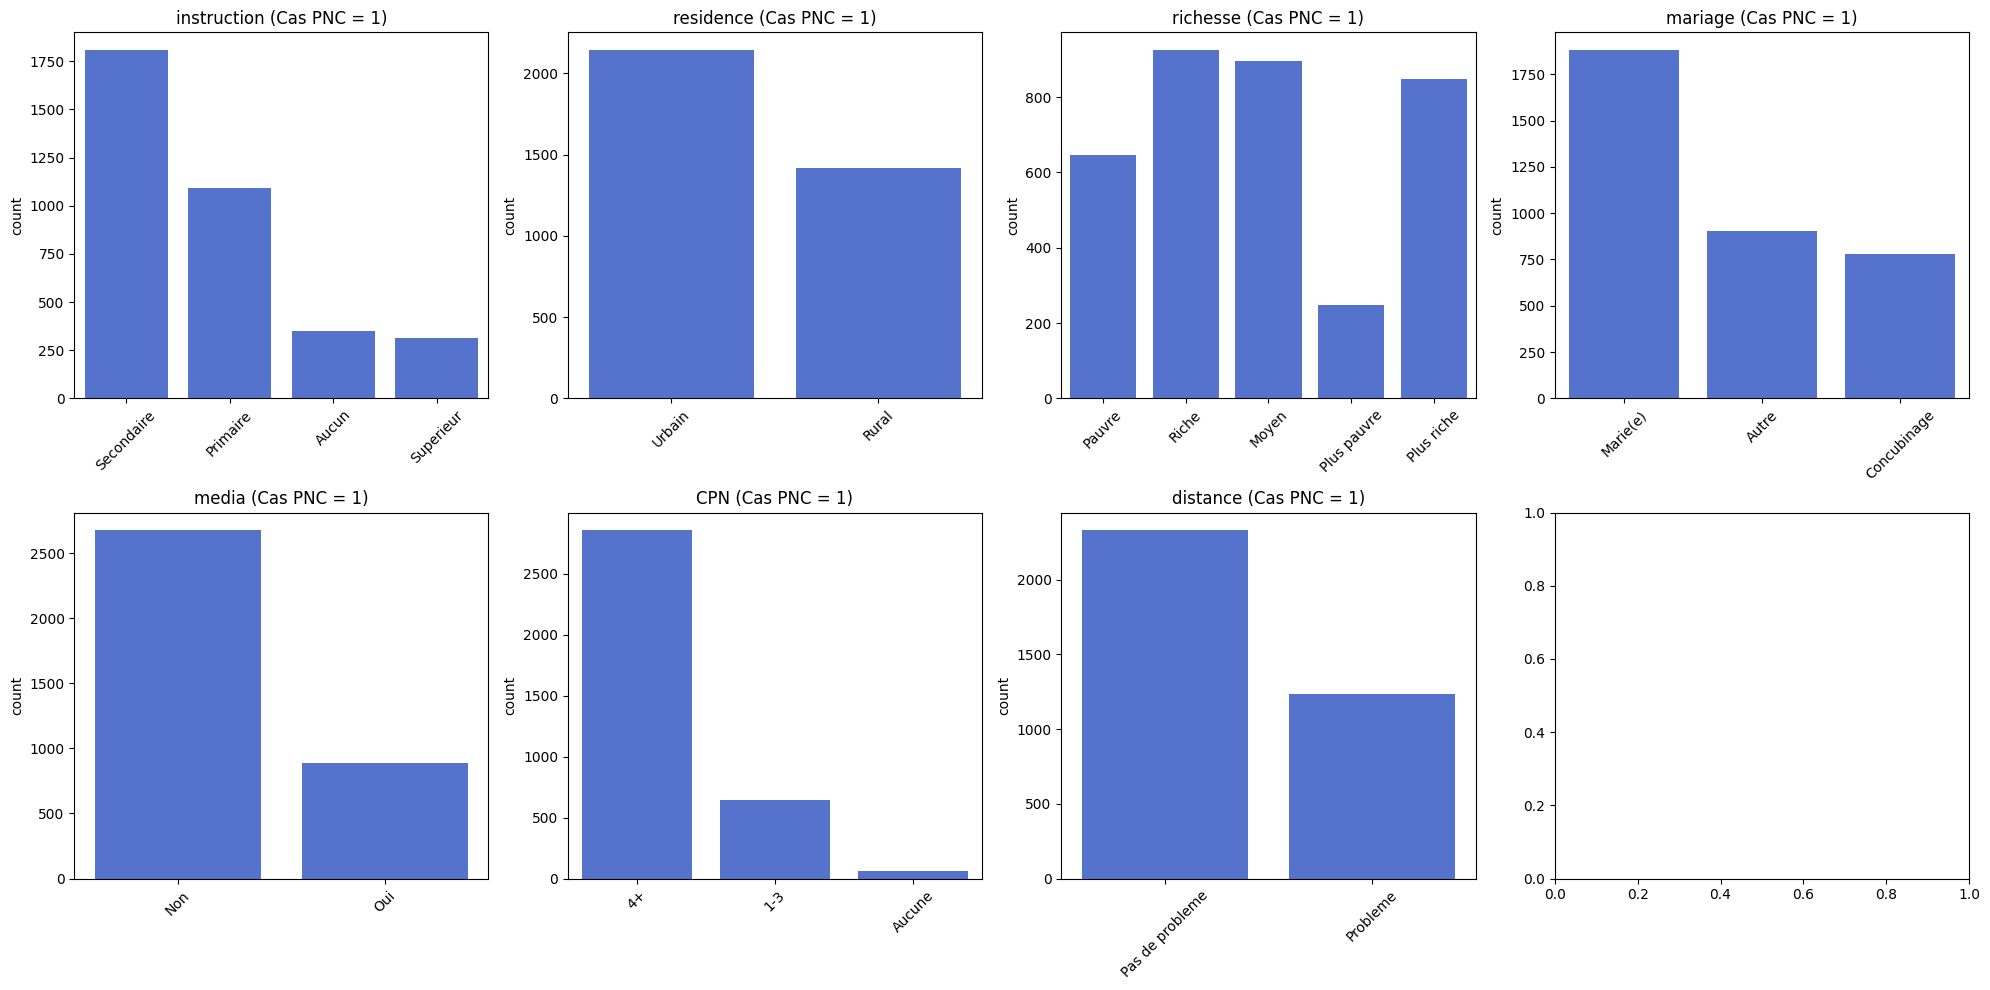

In [124]:
variables = ["instruction", "residence", "richesse",
             "mariage", "media", "CPN", "distance"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(variables):
    # Filtrer le DataFrame pour n'afficher que les cas positifs (PNC = 1)
    sns.countplot(x=var, data=df[df["PNC"] == 1], ax=axes[i], color="royalblue")
   
    axes[i].set_title(f"{var} (Cas PNC = 1)")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

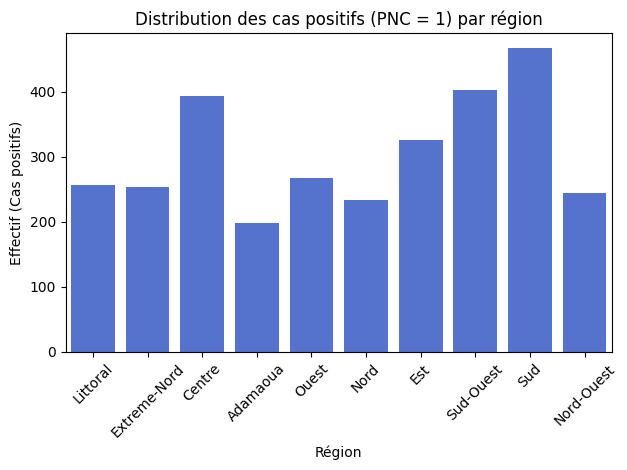

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrer le jeu de données pour ne garder que les lignes où PNC vaut 1
sns.countplot(
    x="region",
    data=df[df["PNC"] == 1],  # <-- C'est ce filtre qui fait tout le travail
    color="royalblue"
)

plt.title("Distribution des cas positifs (PNC = 1) par région")
plt.xlabel("Région")
plt.ylabel("Effectif (Cas positifs)")
plt.xticks(rotation=45)
plt.tight_layout()  # Évite que les noms des régions soient coupés en bas
plt.show()

In [126]:
variables = ["age_groupe", "instruction", "residence", "richesse", 
             "mariage", "occupation", "media", "CPN", "parite", "distance", "region"]

print(f"{'Variable':<15} {'Chi2':>10} {'p-value':>12} {'Significatif':>15}")
print("-"*55)

for var in variables:
    table = pd.crosstab(df[var], df["PNC"])
    chi2, p, dof, expected = chi2_contingency(table)
    sig = "✅ Oui" if p < 0.20 else "❌ Non"
    print(f"{var:<15} {chi2:>10.2f} {p:>12.4f} {sig:>15}")

Variable              Chi2      p-value    Significatif
-------------------------------------------------------
age_groupe            0.09       0.9571           ❌ Non
instruction          13.47       0.0037           ✅ Oui
residence             9.20       0.0024           ✅ Oui
richesse             28.24       0.0000           ✅ Oui
mariage              11.28       0.0036           ✅ Oui
occupation            0.00       0.9478           ❌ Non
media                13.70       0.0002           ✅ Oui
CPN                  25.63       0.0000           ✅ Oui
parite                2.31       0.3144           ❌ Non
distance             18.74       0.0000           ✅ Oui
region               98.99       0.0000           ✅ Oui


In [127]:
for var in ["age_groupe", "occupation", "parite"]:
    table = pd.crosstab(df[var], df["PNC"])
    chi2, p, dof, expected = chi2_contingency(table)
    print(f"{var}: p = {p:.4f}")

age_groupe: p = 0.9571
occupation: p = 0.9478
parite: p = 0.3144


In [128]:
cols_a_supprimer = ["M62$1", "V012", "V106", "V025", "V024", "V190", 
                    "V130", "V501", "V714", "V157", "V158", "V467C", 
                    "V467D", "M14$1", "V218", "V213",
                    "age_groupe", "occupation", "parite"]

df = df.drop(columns=cols_a_supprimer)
print(df.columns.tolist())

['V005', 'PNC', 'instruction', 'residence', 'richesse', 'mariage', 'media', 'CPN', 'distance', 'poids', 'region']


In [129]:
df

,V005,PNC,instruction,residence,richesse,mariage,media,CPN,distance,poids,region
0,990064,1,Secondaire,Urbain,Pauvre,Marie(e),Non,4+,Pas de probleme,0.990064,Littoral
1,990064,1,Secondaire,Urbain,Riche,Marie(e),Oui,4+,Probleme,0.990064,Littoral
2,990064,0,Primaire,Urbain,Moyen,Marie(e),Non,1-3,Probleme,0.990064,Littoral
3,990064,0,Aucun,Urbain,Moyen,Marie(e),Non,1-3,Pas de probleme,0.990064,Littoral
4,990064,1,Primaire,Urbain,Pauvre,Marie(e),Non,4+,Probleme,0.990064,Littoral
...,...,...,...,...,...,...,...,...,...,...,...
4543,1117141,1,Primaire,Rural,Moyen,Autre,Non,4+,Pas de probleme,1.117141,Nord-Ouest
4544,1117141,0,Primaire,Rural,Pauvre,Marie(e),Non,4+,Pas de probleme,1.117141,Nord-Ouest
4545,1330409,1,Aucun,Rural,Plus pauvre,Marie(e),Non,4+,Pas de probleme,1.330409,Nord-Ouest
4546,1330409,1,Aucun,Rural,Pauvre,Marie(e),Non,4+,Pas de probleme,1.330409,Nord-Ouest


In [130]:
#Encodage des variables
df_model = pd.get_dummies(df.drop(columns=["poids"]), 
                          columns=["richesse", "distance", "CPN", "media",
                                   "residence", "mariage", "instruction", "region"],
                          drop_first=True)

print(df_model.shape)
print(df_model.columns.tolist())

(4548, 25)
['V005', 'PNC', 'richesse_Pauvre', 'richesse_Plus pauvre', 'richesse_Plus riche', 'richesse_Riche', 'distance_Probleme', 'CPN_4+', 'CPN_Aucune', 'media_Oui', 'residence_Urbain', 'mariage_Concubinage', 'mariage_Marie(e)', 'instruction_Primaire', 'instruction_Secondaire', 'instruction_Superieur', 'region_Centre', 'region_Est', 'region_Extreme-Nord', 'region_Littoral', 'region_Nord', 'region_Nord-Ouest', 'region_Ouest', 'region_Sud', 'region_Sud-Ouest']


In [131]:
df_model

,V005,PNC,richesse_Pauvre,richesse_Plus pauvre,richesse_Plus riche,richesse_Riche,distance_Probleme,CPN_4+,CPN_Aucune,media_Oui,...,instruction_Superieur,region_Centre,region_Est,region_Extreme-Nord,region_Littoral,region_Nord,region_Nord-Ouest,region_Ouest,region_Sud,region_Sud-Ouest
0,990064,1,True,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
1,990064,1,False,False,False,True,True,True,False,True,...,False,False,False,False,True,False,False,False,False,False
2,990064,0,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,990064,0,False,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,990064,1,True,False,False,False,True,True,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4543,1117141,1,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4544,1117141,0,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4545,1330409,1,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
4546,1330409,1,True,False,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False


In [132]:
x = df_model.drop(columns=["PNC"])
y = df_model["PNC"]

In [133]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [134]:
print(f"Train: {x_train.shape}")
print(f"Train: {x_test.shape}")

Train: (3638, 24)
Train: (910, 24)


In [135]:
#variable richesse uniquement 
x_simple = df_model[[col for col in df_model.columns if "richesse" in col]]


In [136]:
x_simple = x_simple.replace({True: 1, False:0}).astype(int)
x_simple = sm.add_constant(x_simple)

C:\Users\JOHANN\AppData\Local\Temp\ipykernel_17208\1210952656.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  x_simple = x_simple.replace({True: 1, False:0}).astype(int)


In [137]:
print(x_simple.dtypes)

const                   float64
richesse_Pauvre           int64
richesse_Plus pauvre      int64
richesse_Plus riche       int64
richesse_Riche            int64
dtype: object


## regardons le rapport statistique pour la variable richesse

In [138]:
model1 = sm.Logit(y, x_simple).fit()
print(model1.summary())

Optimization terminated successfully.
         Current function value: 0.518717
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    PNC   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4543
Method:                           MLE   Df Model:                            4
Date:               ven., 22 mai 2026   Pseudo R-squ.:                0.006246
Time:                        12:02:30   Log-Likelihood:                -2359.1
converged:                       True   LL-Null:                       -2374.0
Covariance Type:            nonrobust   LLR p-value:                 5.749e-06
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                    1.1455      0.068     16.843      0.000       1.012       1.279

In [139]:
df_model = df_model.astype(int)
print(df_model.dtypes)

V005                      int64
PNC                       int64
richesse_Pauvre           int64
richesse_Plus pauvre      int64
richesse_Plus riche       int64
richesse_Riche            int64
distance_Probleme         int64
CPN_4+                    int64
CPN_Aucune                int64
media_Oui                 int64
residence_Urbain          int64
mariage_Concubinage       int64
mariage_Marie(e)          int64
instruction_Primaire      int64
instruction_Secondaire    int64
instruction_Superieur     int64
region_Centre             int64
region_Est                int64
region_Extreme-Nord       int64
region_Littoral           int64
region_Nord               int64
region_Nord-Ouest         int64
region_Ouest              int64
region_Sud                int64
region_Sud-Ouest          int64
dtype: object


In [140]:
df_model = df_model.drop(columns=["V005"])

X = df_model.drop(columns=["PNC"])
y = df_model["PNC"]

print(df_model.shape)

(4548, 24)


In [141]:
X_multiple = sm.add_constant(X)
model2 = sm.Logit(y, X_multiple).fit()
print(model2.summary())

Optimization terminated successfully.
         Current function value: 0.502463
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                    PNC   No. Observations:                 4548
Model:                          Logit   Df Residuals:                     4524
Method:                           MLE   Df Model:                           23
Date:               ven., 22 mai 2026   Pseudo R-squ.:                 0.03739
Time:                        12:02:32   Log-Likelihood:                -2285.2
converged:                       True   LL-Null:                       -2374.0
Covariance Type:            nonrobust   LLR p-value:                 7.765e-26
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      1.0784      0.203      5.308      0.000       0.680      

In [142]:
model3 = sm.GLM(y, X_multiple, 
                family=sm.families.Poisson()).fit()
print(model3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    PNC   No. Observations:                 4548
Model:                            GLM   Df Residuals:                     4524
Model Family:                 Poisson   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4413.5
Date:               ven., 22 mai 2026   Deviance:                       1697.0
Time:                        12:02:34   Pearson chi2:                     983.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.008598
Covariance Type:            nonrobust                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [143]:
model3_robust = sm.GLM(y, X_multiple, 
                family=sm.families.Poisson()).fit(cov_type='HC3')
print(model3_robust.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                    PNC   No. Observations:                 4548
Model:                            GLM   Df Residuals:                     4524
Model Family:                 Poisson   Df Model:                           23
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -4413.5
Date:               ven., 22 mai 2026   Deviance:                       1697.0
Time:                        12:02:34   Pearson chi2:                     983.
No. Iterations:                     4   Pseudo R-squ. (CS):           0.008598
Covariance Type:                  HC3                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -0

In [144]:
from statsmodels.regression.mixed_linear_model import MixedLM

# Encoder region comme variable numérique de groupe
groups = pd.Categorical(df["region"]).codes

model_multi = MixedLM(y, X_multiple, groups=groups)
result_multi = model_multi.fit()
print(result_multi.summary())

c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\JOHANN\Documents\environement python\IABD\IABDJOHANN\lib\site-packages\statsmodels\regression\mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    PNC       
No. Observations:    4548       Method:                REML      
No. Groups:          11         Scale:                 0.1636    
Min. group size:     234        Log-Likelihood:        -2399.2743
Max. group size:     608        Converged:             Yes       
Mean group size:     413.5                                       
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
const                   0.739    0.072 10.255 0.000  0.598  0.881
richesse_Pauvre         0.022    0.020  1.148 0.251 -0.016  0.061
richesse_Plus pauvre   -0.006    0.029 -0.208 0.835 -0.063  0.051
richesse_Plus riche     0.045    0.021  2.113 0.035  0.003  0.087
richesse_Riche         -0.008    0.018 -0.429 0.668 -0.043  0.028
distance_Probleme       

# PARTIE II MACHINE LEARNING

In [145]:
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.model_selection import learning_curve, validation_curve

In [146]:
print(df_model.shape)
print(df_model.columns.tolist())

(4548, 24)
['PNC', 'richesse_Pauvre', 'richesse_Plus pauvre', 'richesse_Plus riche', 'richesse_Riche', 'distance_Probleme', 'CPN_4+', 'CPN_Aucune', 'media_Oui', 'residence_Urbain', 'mariage_Concubinage', 'mariage_Marie(e)', 'instruction_Primaire', 'instruction_Secondaire', 'instruction_Superieur', 'region_Centre', 'region_Est', 'region_Extreme-Nord', 'region_Littoral', 'region_Nord', 'region_Nord-Ouest', 'region_Ouest', 'region_Sud', 'region_Sud-Ouest']


In [147]:
df_model.columns.tolist()

['PNC',
 'richesse_Pauvre',
 'richesse_Plus pauvre',
 'richesse_Plus riche',
 'richesse_Riche',
 'distance_Probleme',
 'CPN_4+',
 'CPN_Aucune',
 'media_Oui',
 'residence_Urbain',
 'mariage_Concubinage',
 'mariage_Marie(e)',
 'instruction_Primaire',
 'instruction_Secondaire',
 'instruction_Superieur',
 'region_Centre',
 'region_Est',
 'region_Extreme-Nord',
 'region_Littoral',
 'region_Nord',
 'region_Nord-Ouest',
 'region_Ouest',
 'region_Sud',
 'region_Sud-Ouest']

In [148]:
X = df_model.drop(columns=["PNC"])
y = df_model["PNC"]

print(f"X : {X.shape}")
print(f"y : {y.shape}")
print(f"\nDistribution de y :")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3) * 100)

X : (4548, 23)
y : (4548,)

Distribution de y :
PNC
1    3565
0     983
Name: count, dtype: int64
PNC
1    78.4
0    21.6
Name: proportion, dtype: float64


In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # Pour la reproductibilité
    stratify=y          # ← Important : garde le même ratio 78/22 dans train et test
)

print(f"Train : {X_train.shape} — {y_train.value_counts().to_dict()}")
print(f"Test  : {X_test.shape} — {y_test.value_counts().to_dict()}")

Train : (3638, 23) — {1: 2852, 0: 786}
Test  : (910, 23) — {1: 713, 0: 197}


In [152]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))
print(f"AUC : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.25      0.29      0.27       197
           1       0.79      0.76      0.78       713

    accuracy                           0.66       910
   macro avg       0.52      0.52      0.52       910
weighted avg       0.68      0.66      0.67       910

AUC : 0.5405


In [153]:
from xgboost import XGBClassifier

# scale_pos_weight corrige le déséquilibre : 983/3565 = 0.28
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=100,
    random_state=42,
    scale_pos_weight=scale,  # ← Correction déséquilibre
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:,1]

print("=== XGBOOST ===")
print(classification_report(y_test, y_pred_xgb))
print(f"AUC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

=== XGBOOST ===
              precision    recall  f1-score   support

           0       0.27      0.48      0.35       197
           1       0.82      0.65      0.72       713

    accuracy                           0.61       910
   macro avg       0.55      0.56      0.54       910
weighted avg       0.70      0.61      0.64       910

AUC : 0.5805


In [169]:
from sklearn.linear_model import LogisticRegression

# Initialisation du modèle avec gestion du déséquilibre des classes
# 'balanced' ajuste automatiquement les poids inversement proportionnels aux fréquences des classes
model_lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Entraînement du modèle sur le jeu de données d'apprentissage
print("[INFO] Entraînement de la Régression Logistique (Baseline Prédictive)...")
model_lr.fit(X_train, y_train)

[INFO] Entraînement de la Régression Logistique (Baseline Prédictive)...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [170]:
# Prédiction des classes (0 ou 1)
y_pred_lr = model_lr.predict(X_test)

# Prédiction des probabilités (nécessaire pour l'AUC et la courbe ROC)
y_proba_lr = model_lr.predict_proba(X_test)[:, 1]

In [171]:
from sklearn.metrics import classification_report, roc_auc_score

# Génération du rapport de classification (Precision, Recall, F1-score)
print("\n=== CLASSIFICATION REPORT (REGRESSION LOGISTIQUE) ===")
print(classification_report(y_test, y_pred_lr))

# Calcul du score AUC-ROC
auc_score = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC Score : {auc_score:.4f}")


=== CLASSIFICATION REPORT (REGRESSION LOGISTIQUE) ===
              precision    recall  f1-score   support

           0       0.28      0.54      0.37       197
           1       0.83      0.61      0.70       713

    accuracy                           0.60       910
   macro avg       0.55      0.58      0.54       910
weighted avg       0.71      0.60      0.63       910

AUC-ROC Score : 0.6060


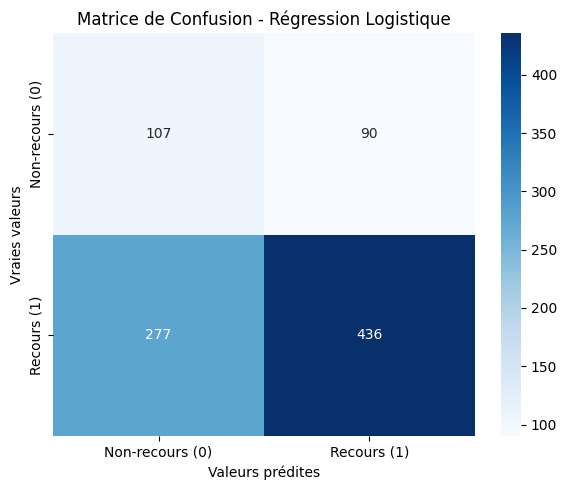

In [ ]:
from sklearn.metrics import confusion_matrix

# Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_lr)

# Affichage graphique
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-recours (0)', 'Recours (1)'],
            yticklabels=['Non-recours (0)', 'Recours (1)'])
plt.title('Matrice de Confusion - Régression Logistique')
plt.ylabel('Vraies valeurs')
plt.xlabel('Valeurs prédites')
plt.tight_layout()
plt.show()

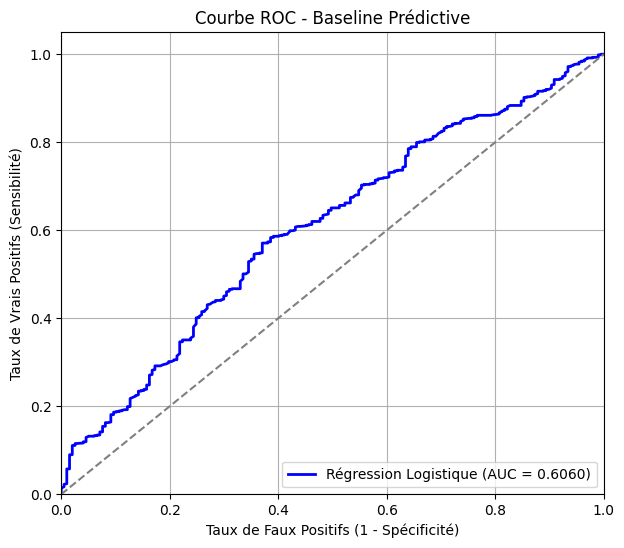

In [173]:
from sklearn.metrics import roc_curve

# Calcul des taux de faux positifs et vrais positifs
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)

# Tracé de la courbe ROC
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Régression Logistique (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Ligne de chance (pile ou face)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (1 - Spécificité)')
plt.ylabel('Taux de Vrais Positifs (Sensibilité)')
plt.title('Courbe ROC - Baseline Prédictive')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

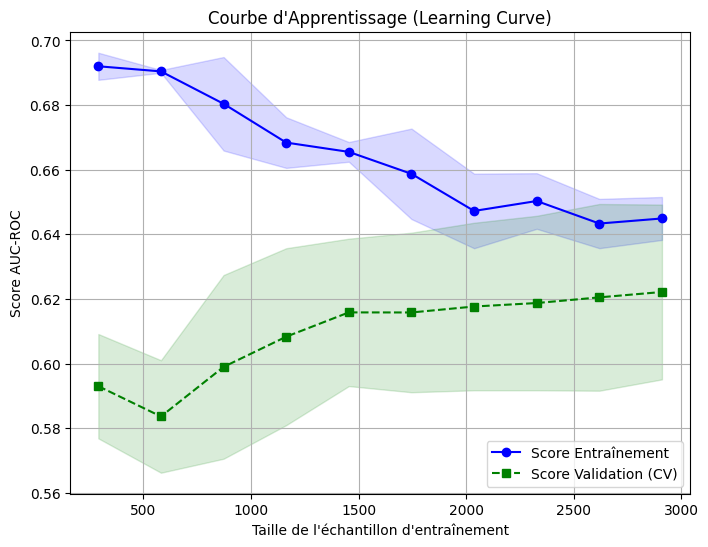

In [ ]:
from sklearn.model_selection import learning_curve

# Calcul des scores pour différentes tailles de sous-échantillons d'entraînement
train_sizes, train_scores, val_scores = learning_curve(
    model_lr, X_train, y_train,
    cv=5, scoring='roc_auc', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    random_state=42
)

# Moyennes et écarts-types
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Tracé graphique
plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', label='Score Entraînement')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='blue')
plt.plot(train_sizes, val_mean, color='green', marker='s', linestyle='--', label='Score Validation (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='green')

plt.title("Courbe d'Apprentissage (Learning Curve)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Score AUC-ROC")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [175]:
from sklearn.model_selection import GridSearchCV

# Définition de la grille des paramètres à tester (C = inverse de la force de régularisation)
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'] # Régularisation Ridge standard
}

# Recherche par grille avec Validation Croisée (Stratified 5-Fold implicite pour classification)
grid_search = GridSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Récupération du meilleur modèle optimisé
best_model_lr = grid_search.best_estimator_
print(f"Meilleurs paramètres trouvés : {grid_search.param_dict_ if hasattr(grid_search, 'param_dict_') else grid_search.best_params_}")
print(f"Meilleur score AUC de validation : {grid_search.best_score_:.4f}")

Meilleurs paramètres trouvés : {'C': 1, 'penalty': 'l2'}
Meilleur score AUC de validation : 0.6221


In [177]:
import joblib

# Définition du nom du fichier de sauvegarde
model_filename = 'model_PNC_Cameroun.pkl'

# Sauvegarde du modèle optimisé
joblib.dump(best_model_lr, model_filename)
print(f"[SUCCESS] Modèle de régression logistique enregistré avec succès sous : '{model_filename}'")

[SUCCESS] Modèle de régression logistique enregistré avec succès sous : 'model_PNC_Cameroun.pkl'


In [178]:
probas = lr.predict_proba(X)[:,1]

print(f"Proba minimum : {probas.min():.4f} ({probas.min()*100:.1f}%)")
print(f"Proba maximum : {probas.max():.4f} ({probas.max()*100:.1f}%)")
print(f"Proba moyenne : {probas.mean():.4f} ({probas.mean()*100:.1f}%)")
print(f"Proba médiane : {np.median(probas):.4f} ({np.median(probas)*100:.1f}%)")

Proba minimum : 0.1749 (17.5%)
Proba maximum : 0.8072 (80.7%)
Proba moyenne : 0.5173 (51.7%)
Proba médiane : 0.5243 (52.4%)
